In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import pandas as pd

df = pd.read_excel("../data/customer_data.xlsx", sheet_name="Customers")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [5]:
# ==========================================
# CELL 2: Load the Excel Dataset & Preliminary Inspection
# ==========================================
file_path = "../data/customer_data.xlsx"

# Load the 'Customers' sheet using openpyxl engine
df = pd.read_excel(file_path, sheet_name="Customers", engine="openpyxl")

print("--- DATASET OVERVIEW ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- FIRST 5 ROWS ---")
display(df.head())

print("\n--- DATA TYPES & NON-NULL COUNTS ---")
df.info()

print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

print("\n--- DUPLICATE RECORDS ---")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

BadZipFile: File is not a zip file

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Load dataset
file_path = "../data/customer_data.xlsx"

df = pd.read_excel(file_path, sheet_name="Customers", engine="openpyxl")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

BadZipFile: File is not a zip file

In [8]:
import os
import pandas as pd

# Check current directory and verify file paths
print("Current Working Directory:", os.getcwd())
file_exists = os.path.exists("../data/customer_data.xlsx")
print("Does '../data/customer_data.xlsx' exist?:", file_exists)

if file_exists:
    try:
        df = pd.read_excel("../data/customer_data.xlsx", sheet_name="Customers", engine="openpyxl")
        print("\nSUCCESS: Dataset loaded successfully!")
        print("Shape:", df.shape)
        display(df.head(2))
    except Exception as e:
        print("\nERROR loading dataset:")
        print(e)
else:
    print("\nFile not found at '../data/customer_data.xlsx'. Checking directory contents:")
    print("Files in parent directory:", os.listdir(".."))
    if os.path.exists("../data"):
        print("Files inside data folder:", os.listdir("../data"))

Current Working Directory: d:\Customer Segmentation Using Clustering\notebooks
Does '../data/customer_data.xlsx' exist?: True

ERROR loading dataset:
File is not a zip file


In [1]:
import pandas as pd

df = pd.read_excel("../data/customers_1500.xlsx", sheet_name="Customers", engine="openpyxl")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (1500, 13)


,CustomerID,Name,Gender,Age,City,Annual Income (k$),Spending Score (1-100),Tenure (months),Total Orders,Total Spend ($),Avg Order Value ($),Days Since Last Purchase,Loyalty Member
0,C0001,Karthik Joshi,Male,38,Hyderabad,25,32,22,11,340.45,30.95,22,Yes
1,C0002,Aisha Rao,Female,38,Pune,40,30,35,10,141.83,14.18,116,No
2,C0003,Isha Kumar,Female,45,Kochi,120,87,19,22,3114.59,141.57,22,No
3,C0004,Riya Kumar,Female,29,Bengaluru,29,66,8,24,571.70,23.82,15,No
4,C0005,Amit Patel,Male,33,Chennai,113,76,35,37,6861.93,185.46,8,Yes


In [2]:
# ==========================================
# CELL 2: Summary Statistics & Categorical Checks
# ==========================================

print("--- NUMERICAL STATISTICAL SUMMARY ---")
display(df.describe().T)

print("\n--- CATEGORICAL FEATURE DISTRIBUTIONS ---")
categorical_cols = ['Gender', 'City', 'Loyalty Member']

for col in categorical_cols:
    print(f"\nValue counts for '{col}':")
    print(df[col].value_counts())
    print("-" * 35)

print("\n--- IDENTIFYING NUMERICAL FEATURE COLUMNS ---")
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("All Numerical Columns:", num_cols)

# Separate identifiers from candidate features
clustering_candidate_features = [col for col in num_cols if col != 'CustomerID']
print("Candidate Features for Clustering:", clustering_candidate_features)

--- NUMERICAL STATISTICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Age,1500.0,36.909333,10.891412,18.00,28.000,36.500,44.000,75.00
Annual Income (k$),1500.0,59.142667,30.737602,12.00,32.000,55.000,84.000,154.00
Spending Score (1-100),1500.0,50.953333,25.919704,1.00,28.000,50.000,75.000,100.00
Tenure (months),1500.0,33.726667,18.568086,1.00,19.000,32.000,46.000,96.00
Total Orders,1500.0,17.070667,10.305750,1.00,8.000,16.000,25.000,55.00
Total Spend ($),1500.0,1519.579080,1815.068763,19.83,376.005,966.035,1656.565,11226.71
Avg Order Value ($),1500.0,82.286467,61.273429,8.00,34.200,61.360,120.860,288.33
Days Since Last Purchase,1500.0,52.566000,62.204694,1.00,12.000,28.000,70.000,365.00



--- CATEGORICAL FEATURE DISTRIBUTIONS ---

Value counts for 'Gender':
Gender
Female    784
Male      716
Name: count, dtype: int64
-----------------------------------

Value counts for 'City':
City
Chennai          218
Hyderabad        206
Bengaluru        195
Mumbai           153
Delhi            147
Visakhapatnam    137
Pune             135
Vijayawada        90
Ahmedabad         85
Kolkata           77
Kochi             32
Jaipur            25
Name: count, dtype: int64
-----------------------------------

Value counts for 'Loyalty Member':
Loyalty Member
Yes    1057
No      443
Name: count, dtype: int64
-----------------------------------

--- IDENTIFYING NUMERICAL FEATURE COLUMNS ---
All Numerical Columns: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Tenure (months)', 'Total Orders', 'Total Spend ($)', 'Avg Order Value ($)', 'Days Since Last Purchase']
Candidate Features for Clustering: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Tenure (months)', 'Total Or

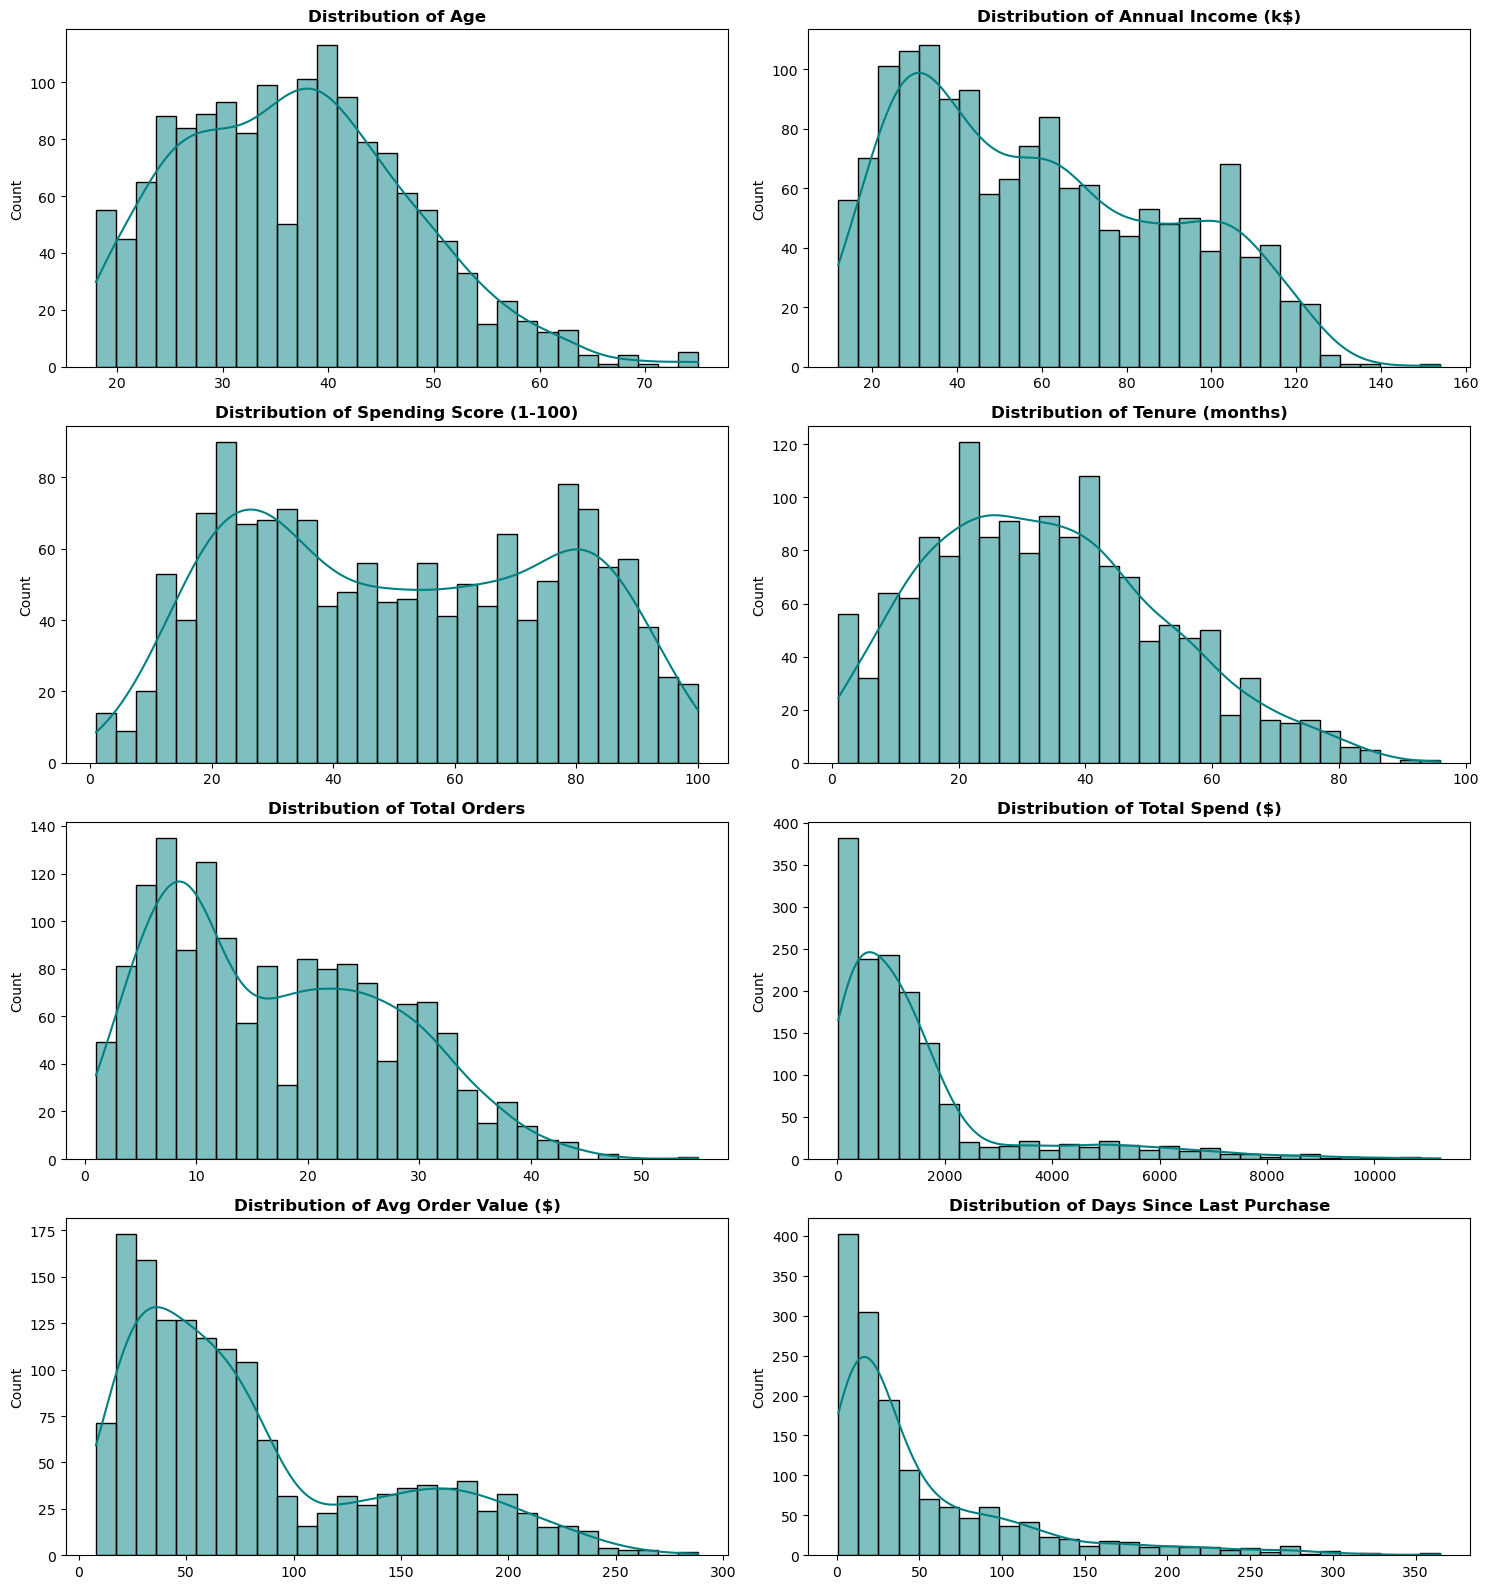

In [4]:
# ==========================================
# CELL 3: Feature Distributions (EDA Part 1)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

num_features = [
    'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 
    'Tenure (months)', 'Total Orders', 'Total Spend ($)', 
    'Avg Order Value ($)', 'Days Since Last Purchase'
]

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

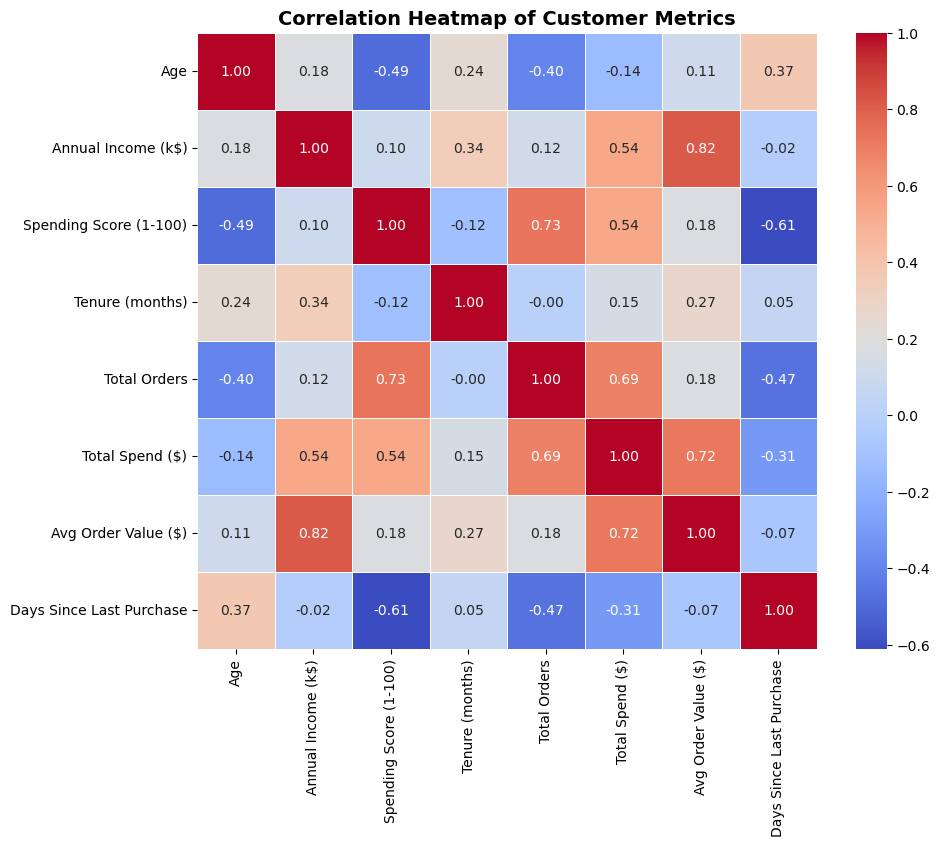

In [5]:
# ==========================================
# CELL 4: Feature Correlations (EDA Part 2)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Compute correlation matrix for numerical features
corr_matrix = df[num_features].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Customer Metrics', fontsize=14, fontweight='bold')
plt.show()

In [6]:
# ==========================================
# CELL 5: Feature Selection & Scaling
# ==========================================
from sklearn.preprocessing import StandardScaler

# Select numerical features for clustering (excluding identifiers like CustomerID and Name)
features_to_scale = [
    'Age', 
    'Annual Income (k$)', 
    'Spending Score (1-100)', 
    'Tenure (months)', 
    'Total Orders', 
    'Total Spend ($)', 
    'Avg Order Value ($)', 
    'Days Since Last Purchase'
]

X = df[features_to_scale]

# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for verification
X_scaled_df = pd.DataFrame(X_scaled, columns=features_to_scale)

print("--- FEATURE SCALING COMPLETED ---")
print("Scaled Data Shape:", X_scaled_df.shape)
print("\n--- FIRST 5 ROWS OF SCALED DATA (Mean ≈ 0, Std ≈ 1) ---")
display(X_scaled_df.head())

--- FEATURE SCALING COMPLETED ---
Scaled Data Shape: (1500, 8)

--- FIRST 5 ROWS OF SCALED DATA (Mean ≈ 0, Std ≈ 1) ---


,Age,Annual Income (k$),Spending Score (1-100),Tenure (months),Total Orders,Total Spend ($),Avg Order Value ($),Days Since Last Purchase
0,0.100173,-1.111149,-0.731477,-0.631760,-0.589253,-0.649850,-0.838105,-0.491542
1,0.100173,-0.622985,-0.808664,0.068599,-0.686318,-0.759315,-1.111888,1.020102
2,0.743096,1.980559,1.391169,-0.793382,0.478469,0.879054,0.967847,-0.491542
3,-0.726441,-0.980972,0.580704,-1.385994,0.672600,-0.522402,-0.954508,-0.604111
4,-0.359057,1.752749,0.966640,0.068599,1.934452,2.944314,1.684383,-0.716680


c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, pree

K =  2 | WCSS (Inertia):    8650.54 | Silhouette Score: 0.2581
K =  3 | WCSS (Inertia):    6561.27 | Silhouette Score: 0.2840


c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


K =  4 | WCSS (Inertia):    5295.70 | Silhouette Score: 0.3064
K =  5 | WCSS (Inertia):    4187.13 | Silhouette Score: 0.3407


c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


...

K =  8 | WCSS (Inertia):    3065.70 | Silhouette Score: 0.3190


c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


K =  9 | WCSS (Inertia):    2875.46 | Silhouette Score: 0.2827


c:\Users\SAI ADITHYA\anaconda3\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


K = 10 | WCSS (Inertia):    2774.97 | Silhouette Score: 0.2587


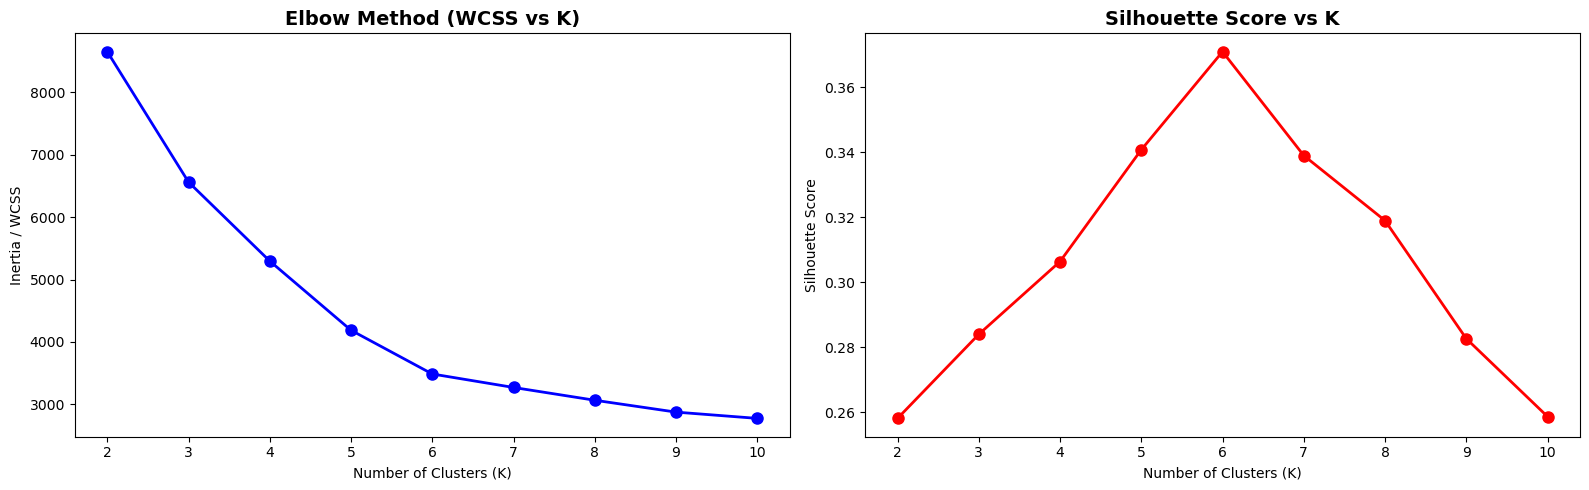

In [7]:
# ==========================================
# CELL 6: Elbow Method & Silhouette Analysis
# ==========================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []            # Within-Cluster Sum of Squares (Inertia)
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | WCSS (Inertia): {kmeans.inertia_:10.2f} | Silhouette Score: {score:.4f}")

# Plotting Elbow Curve and Silhouette Scores side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method Plot
ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method (WCSS vs K)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia / WCSS')
ax1.set_xticks(list(k_range))

# Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# CELL 7: Final K-Means Model Training (K = 6)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

OPTIMAL_K = 6

# Train Final KMeans model
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original DataFrame
df['Cluster'] = cluster_labels

print(f"--- K-MEANS TRAINED SUCCESSFULLY WITH K = {OPTIMAL_K} ---")
print("\nCluster Distribution (Customer Counts):")
print(df['Cluster'].value_counts().sort_index())

print("\n--- FIRST 5 ROWS WITH CLUSTER ASSIGNMENTS ---")
display(df[['CustomerID', 'Name', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Total Spend ($)', 'Cluster']].head())

--- K-MEANS TRAINED SUCCESSFULLY WITH K = 6 ---

Cluster Distribution (Customer Counts):
Cluster
0    307
1    205
2    225
3    353
4    296
5    114
Name: count, dtype: int64

--- FIRST 5 ROWS WITH CLUSTER ASSIGNMENTS ---


,CustomerID,Name,Age,Annual Income (k$),Spending Score (1-100),Total Spend ($),Cluster
0,C0001,Karthik Joshi,38,25,32,340.45,0
1,C0002,Aisha Rao,38,40,30,141.83,0
2,C0003,Isha Kumar,45,120,87,3114.59,1
3,C0004,Riya Kumar,29,29,66,571.70,4
4,C0005,Amit Patel,33,113,76,6861.93,1


In [9]:
# ==========================================
# CELL 8: Cluster Profiling & Feature Means
# ==========================================

# Group by Cluster and compute mean values for each feature
cluster_profile = df.groupby('Cluster')[features_to_scale].mean().reset_index()

print("--- CLUSTER FEATURE MEANS (PROFILING TABLE) ---")
display(cluster_profile.round(2))

--- CLUSTER FEATURE MEANS (PROFILING TABLE) ---


,Cluster,Age,Annual Income (k$),Spending Score (1-100),Tenure (months),Total Orders,Total Spend ($),Avg Order Value ($),Days Since Last Purchase
0,0,40.19,26.24,29.80,23.86,8.06,209.82,25.91,60.96
1,1,33.69,99.30,84.74,36.36,30.16,5486.66,182.42,9.94
2,2,44.63,97.82,25.03,39.33,6.14,943.01,151.66,84.55
3,3,38.34,61.01,55.19,51.43,20.41,1453.92,71.25,25.17
4,4,24.70,36.34,76.18,15.05,24.30,1004.69,41.55,16.65
5,5,45.90,52.64,19.68,38.18,10.27,591.12,57.08,221.58


In [10]:
# ==========================================
# CELL 9: Map Cluster IDs to Business Segment Names
# ==========================================

# Define cluster name mapping based on data analysis
segment_map = {
    0: 'Budget / Low-Value Customers',
    1: 'VIP / High-Value Champions',
    2: 'High-Income Conservative Shoppers',
    3: 'Steady / Long-Term Regulars',
    4: 'Young Impulse Trendsetters',
    5: 'At-Risk / Churned Customers'
}

# Map names to DataFrame
df['Segment_Name'] = df['Cluster'].map(segment_map)

print("--- SEGMENT NAME MAPPING COMPLETED ---")
print("\nSegment Customer Distribution:")
print(df['Segment_Name'].value_counts())

print("\n--- FIRST 5 ROWS WITH BUSINESS SEGMENT NAMES ---")
display(df[['CustomerID', 'Name', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Total Spend ($)', 'Cluster', 'Segment_Name']].head())

--- SEGMENT NAME MAPPING COMPLETED ---

Segment Customer Distribution:
Segment_Name
Steady / Long-Term Regulars          353
Budget / Low-Value Customers         307
Young Impulse Trendsetters           296
High-Income Conservative Shoppers    225
VIP / High-Value Champions           205
At-Risk / Churned Customers          114
Name: count, dtype: int64

--- FIRST 5 ROWS WITH BUSINESS SEGMENT NAMES ---


,CustomerID,Name,Age,Annual Income (k$),Spending Score (1-100),Total Spend ($),Cluster,Segment_Name
0,C0001,Karthik Joshi,38,25,32,340.45,0,Budget / Low-Value Customers
1,C0002,Aisha Rao,38,40,30,141.83,0,Budget / Low-Value Customers
2,C0003,Isha Kumar,45,120,87,3114.59,1,VIP / High-Value Champions
3,C0004,Riya Kumar,29,29,66,571.70,4,Young Impulse Trendsetters
4,C0005,Amit Patel,33,113,76,6861.93,1,VIP / High-Value Champions


In [11]:
# ==========================================
# CELL 10: Save Trained Scaler & KMeans Model
# ==========================================
import joblib
import os

# Ensure models directory exists
os.makedirs("../models", exist_ok=True)

scaler_filename = "../models/scaler.pkl"
model_filename = "../models/kmeans_model.pkl"

# Save fitted objects
joblib.dump(scaler, scaler_filename)
joblib.dump(kmeans, model_filename)

print("--- MODEL SAVING COMPLETED ---")
print(f"1. Scaler saved successfully at: {scaler_filename}")
print(f"2. KMeans model saved successfully at: {model_filename}")

--- MODEL SAVING COMPLETED ---
1. Scaler saved successfully at: ../models/scaler.pkl
2. KMeans model saved successfully at: ../models/kmeans_model.pkl


In [13]:
# ==========================================
# CELL 11: Test Load & Predict New Customer
# ==========================================
import joblib
import numpy as np

# Load saved model & scaler
loaded_scaler = joblib.load("../models/scaler.pkl")
loaded_kmeans = joblib.load("../models/kmeans_model.pkl")

# Define segment mapping dictionary
segment_map = {
    0: 'Budget / Low-Value Customers',
    1: 'VIP / High-Value Champions',
    2: 'High-Income Conservative Shoppers',
    3: 'Steady / Long-Term Regulars',
    4: 'Young Impulse Trendsetters',
    5: 'At-Risk / Churned Customers'
}

# Example new customer feature vector:
# [Age, Annual Income (k$), Spending Score (1-100), Tenure (months), Total Orders, Total Spend ($), Avg Order Value ($), Days Since Last Purchase]
new_customer_data = np.array([[32, 105, 88, 30, 28, 5200.0, 185.0, 10]])

# 1. Scale feature vector
new_customer_scaled = loaded_scaler.transform(new_customer_data)

# 2. Predict cluster
predicted_cluster = loaded_kmeans.predict(new_customer_scaled)[0]
predicted_segment = segment_map[predicted_cluster]

print("--- NEW CUSTOMER PREDICTION TEST ---")
print(f"Predicted Cluster ID: {predicted_cluster}")
print(f"Predicted Business Segment: {predicted_segment}")

--- NEW CUSTOMER PREDICTION TEST ---
Predicted Cluster ID: 1
Predicted Business Segment: VIP / High-Value Champions
